In [35]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns

# Import các thư viện mô hình
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from catboost import CatBoostClassifier

# Import thư viện đánh giá
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve, accuracy_score

In [36]:
train_csv = pd.read_csv('../data/processed/train.csv')
test_csv = pd.read_csv('../data/processed/test.csv')
print(train_csv.shape, test_csv.shape)

(3750, 11) (662, 11)


In [37]:
# 2. TIỀN XỬ LÝ (Mã hóa dữ liệu về dạng số)
target_col = "SOURCE"

# Xử lý train
X_train = train_csv.drop(columns=[target_col])
y_train = train_csv[target_col].map({"in": 0, "out": 1}).astype(int)

# Xử lý tập Test
X_test = test_csv.drop(columns=[target_col])
y_test = test_csv[target_col].map({'in': 0, 'out': 1}).astype(int)

# One-Hot Encoding cho cột SEX (biến đổi F/M thành 0/1)
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# Đảm bảo thứ tự cột giống nhau
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(f"Kích thước tập Train: {X_train.shape}")
print(f"Kích thước tập Test: {X_test.shape}")
print("-" * 30)

Kích thước tập Train: (3750, 10)
Kích thước tập Test: (662, 10)
------------------------------


In [38]:
# 3. KHỞI TẠO CÁC MÔ HÌNH
models = {
    # --- Mô hình cơ bản (Baseline) ---
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    
    # --- Mô hình cây đơn lẻ & Bagging ---
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5),
    
    # --- Mô hình Boosting (Họ hàng của XGBoost) ---
    "XGBoost (Lib)": xgb.XGBClassifier(
        n_estimators=100, 
        learning_rate=0.1, 
        max_depth=5, 
        random_state=42, 
        eval_metric='logloss'
    ),
    
    "CatBoost": CatBoostClassifier(
        iterations=100, 
        learning_rate=0.1, 
        depth=5, 
        random_seed=42, 
        verbose=0   # Tắt log in ra màn hình cho gọn
    )
}

In [39]:
# 4. HUẤN LUYỆN VÀ ĐÁNH GIÁ
results = []

for name, model in models.items():
    print(f"Dang huan luyen {name}...")
    
    # Đo thời gian huấn luyện
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    # Dự đoán
    y_pred = model.predict(X_test)
    
    # Tính độ chính xác
    acc = accuracy_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Time (s)": train_time
    })
    
    print(f"  -> Accuracy: {acc:.4f}")
    print(f"  -> Time: {train_time:.4f}s")
    print("-" * 30)

Dang huan luyen Logistic Regression...
  -> Accuracy: 0.7326
  -> Time: 0.1035s
------------------------------
Dang huan luyen Decision Tree...
  -> Accuracy: 0.7296
  -> Time: 0.0096s
------------------------------
Dang huan luyen Random Forest...
  -> Accuracy: 0.7462
  -> Time: 0.2917s
------------------------------
Dang huan luyen XGBoost (Lib)...
  -> Accuracy: 0.7749
  -> Time: 0.0684s
------------------------------
Dang huan luyen CatBoost...
  -> Accuracy: 0.7568
  -> Time: 0.1545s
------------------------------


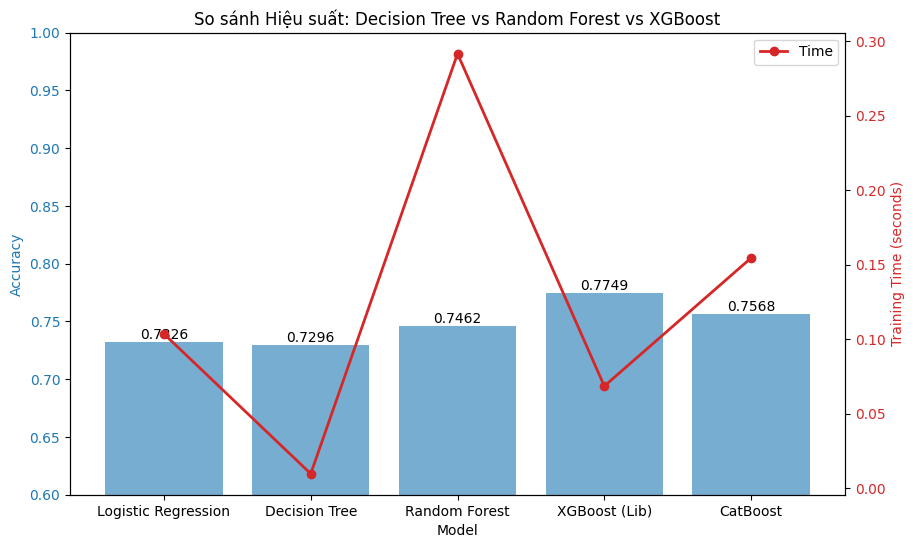


BẢNG TỔNG HỢP KẾT QUẢ:
                 Model  Accuracy  Time (s)
0  Logistic Regression  0.732628  0.103508
1        Decision Tree  0.729607  0.009595
2        Random Forest  0.746224  0.291693
3        XGBoost (Lib)  0.774924  0.068441
4             CatBoost  0.756798  0.154497


In [40]:
# 5. TRỰC QUAN HÓA SO SÁNH
df_results = pd.DataFrame(results)

fig, ax1 = plt.subplots(figsize=(10, 6))

# Vẽ biểu đồ cột cho Accuracy
color = 'tab:blue'
ax1.set_xlabel('Model')
ax1.set_ylabel('Accuracy', color=color)
bars = ax1.bar(df_results['Model'], df_results['Accuracy'], color=color, alpha=0.6, label='Accuracy')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(0.6, 1.0) # Giới hạn trục Y để nhìn rõ sự khác biệt

# Hiển thị giá trị lên cột
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 4), ha='center', va='bottom')

# Vẽ biểu đồ đường cho Thời gian (trục phụ)
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Training Time (seconds)', color=color)
ax2.plot(df_results['Model'], df_results['Time (s)'], color=color, marker='o', linestyle='-', linewidth=2, label='Time')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('So sánh Hiệu suất: Decision Tree vs Random Forest vs XGBoost')
plt.legend()
plt.show()

# Hiển thị bảng kết quả chi tiết
print("\nBẢNG TỔNG HỢP KẾT QUẢ:")
print(df_results)

Model                | Acc      | Prec     | Recall   | F1       | AUC      | Time(s) 
------------------------------------------------------------------------------------------
Logistic Regression  | 0.7326   | 0.7275   | 0.8807   | 0.7968   | 0.7833   | 0.1175
Decision Tree        | 0.7296   | 0.7352   | 0.8528   | 0.7897   | 0.7536   | 0.0094
Random Forest        | 0.7462   | 0.7457   | 0.8706   | 0.8033   | 0.8014   | 0.2908
XGBoost (Lib)        | 0.7749   | 0.7740   | 0.8782   | 0.8228   | 0.8306   | 0.0586
CatBoost             | 0.7568   | 0.7595   | 0.8655   | 0.8090   | 0.8220   | 0.1459


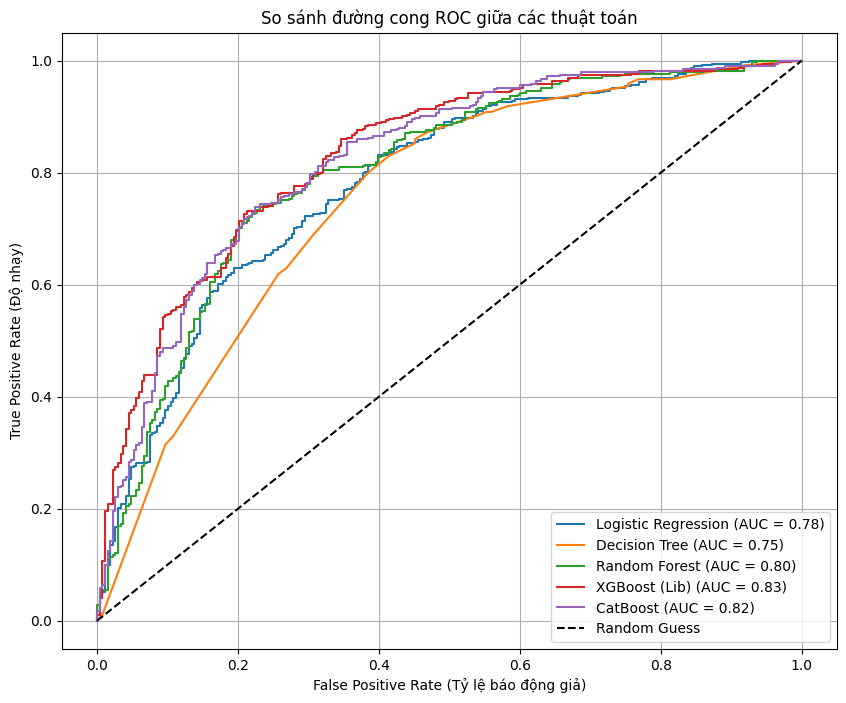

C:\Users\HP\AppData\Local\Temp\ipykernel_23652\2048111375.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='F1-Score', data=res_df, palette='viridis')


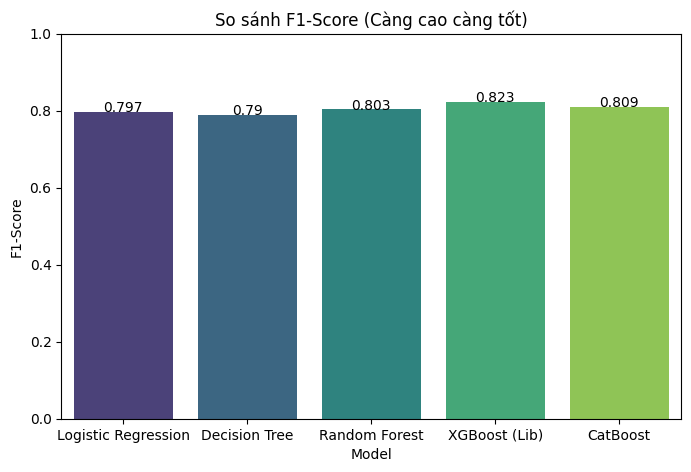

In [41]:
print(f"{'Model':<20} | {'Acc':<8} | {'Prec':<8} | {'Recall':<8} | {'F1':<8} | {'AUC':<8} | {'Time(s)':<8}")
print("-" * 90)

results = []
plt.figure(figsize=(10, 8))

for name, model in models.items():
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    # Dự đoán nhãn (0/1) và xác suất (probability)
    y_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = y_pred # Fallback nếu không có predict_proba

    # Tính các chỉ số
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_prob)
    
    # In kết quả dạng bảng
    print(f"{name:<20} | {acc:.4f}   | {prec:.4f}   | {rec:.4f}   | {f1:.4f}   | {auc:.4f}   | {train_time:.4f}")
    
    results.append({
        "Model": name, "Accuracy": acc, "Precision": prec, 
        "Recall": rec, "F1-Score": f1, "AUC": auc, "Time": train_time
    })

    # Vẽ đường ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.2f})')

# Cấu hình biểu đồ ROC
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate (Tỷ lệ báo động giả)')
plt.ylabel('True Positive Rate (Độ nhạy)')
plt.title('So sánh đường cong ROC giữa các thuật toán')
plt.legend()
plt.grid(True)
plt.show()

# Trực quan hóa F1-Score (Chỉ số quan trọng nhất khi dữ liệu mất cân bằng)
res_df = pd.DataFrame(results)
plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='F1-Score', data=res_df, palette='viridis')
plt.title('So sánh F1-Score (Càng cao càng tốt)')
plt.ylim(0, 1.0)
for index, row in res_df.iterrows():
    plt.text(index, row['F1-Score'], round(row['F1-Score'], 3), color='black', ha="center")
plt.show()

Model                | Train Acc  | Test Acc   | Gap (Overfit)  
-----------------------------------------------------------------
Logistic Regression  | 0.7163     | 0.7326     | -0.0164
Decision Tree        | 1.0000     | 0.6707     | 0.3293
Random Forest        | 0.7667     | 0.7462     | 0.0204
XGBoost (Lib)        | 0.8237     | 0.7704     | 0.0533
CatBoost             | 0.7776     | 0.7568     | 0.0208


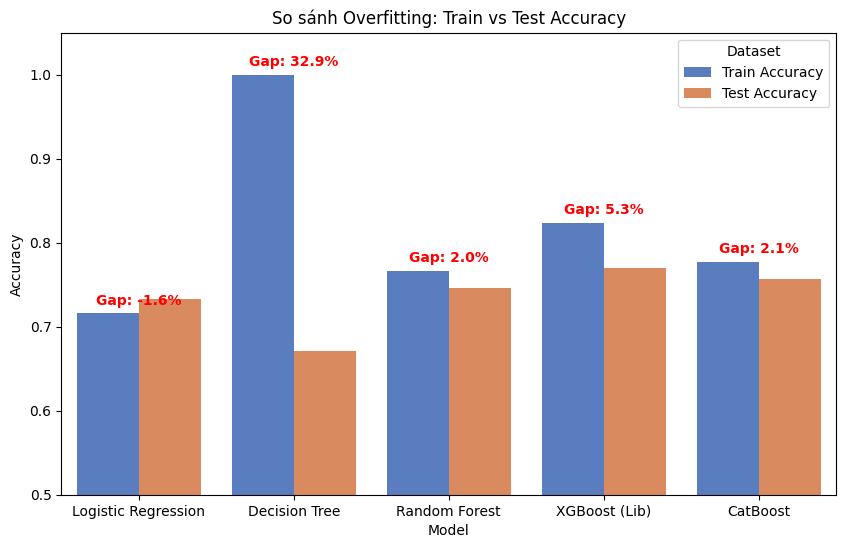

In [66]:
# 3. KHỞI TẠO CÁC MÔ HÌNH
models = {
    # --- Mô hình cơ bản (Baseline) ---
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    
    # --- Mô hình cây đơn lẻ & Bagging ---
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5),
    
    # --- Mô hình Boosting (Họ hàng của XGBoost) ---
    "XGBoost (Lib)": xgb.XGBClassifier(
        n_estimators=100, 
        learning_rate=0.05, 
        max_depth=5, 
        random_state=42, 
        eval_metric='logloss'
    ),
    
    "CatBoost": CatBoostClassifier(
        iterations=100, 
        learning_rate=0.1, 
        depth=5, 
        random_seed=42, 
        verbose=0   # Tắt log in ra màn hình cho gọn
    )
}

# 4. SO SÁNH TRAIN vs TEST
results = []

print(f"{'Model':<20} | {'Train Acc':<10} | {'Test Acc':<10} | {'Gap (Overfit)':<15}")
print("-" * 65)

for name, model in models.items():
    model.fit(X_train, y_train)
    
    # Dự đoán trên cả 2 tập
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    gap = train_acc - test_acc
    
    results.append({
        "Model": name,
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "Gap": gap
    })
    
    print(f"{name:<20} | {train_acc:.4f}     | {test_acc:.4f}     | {gap:.4f}")

# 5. TRỰC QUAN HÓA
df_results = pd.DataFrame(results)
df_melted = df_results.melt(id_vars="Model", value_vars=["Train Accuracy", "Test Accuracy"], var_name="Dataset", value_name="Accuracy")

plt.figure(figsize=(10, 6))
sns.barplot(data=df_melted, x="Model", y="Accuracy", hue="Dataset", palette="muted")
plt.title("So sánh Overfitting: Train vs Test Accuracy")
plt.ylim(0.5, 1.05)

# Hiển thị Gap lên biểu đồ
for i, row in df_results.iterrows():
    plt.text(i, row['Train Accuracy'] + 0.01, f"Gap: {row['Gap']:.1%}", ha='center', color='red', fontweight='bold')

plt.show()